In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Custom modül
import sys
sys.path.append('../')
from src.model_training import ModelTrainer

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


In [11]:
from pathlib import Path

# Tek dosyadan okuma
DATA_FILE = Path(r'C:\Users\PC\Desktop\creditwise\data\processed\train_processed.csv')

df = pd.read_csv(DATA_FILE)

# Hedef ve grup sütunlarını belirle
_target_candidates = ['Credit_Score', 'en']
target_col = next((c for c in _target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError("Hedef sütun bulunamadı. 'Credit_Score' ya da 'en' bekleniyor.")

group_col = 'Customer_ID' if 'Customer_ID' in df.columns else None
if group_col is None:
    raise ValueError("Customer_ID sütunu bulunamadı.")

# Ayrıştırma
y_train = df[target_col]
customer_ids = df[group_col]
X_train = df.drop(columns=[target_col, group_col], errors='ignore')

print("Veri boyutları:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Customer IDs (unique): {customer_ids.nunique()}")

Veri boyutları:
X_train: (58521, 92)
y_train: (58521,)
Customer IDs (unique): 10040


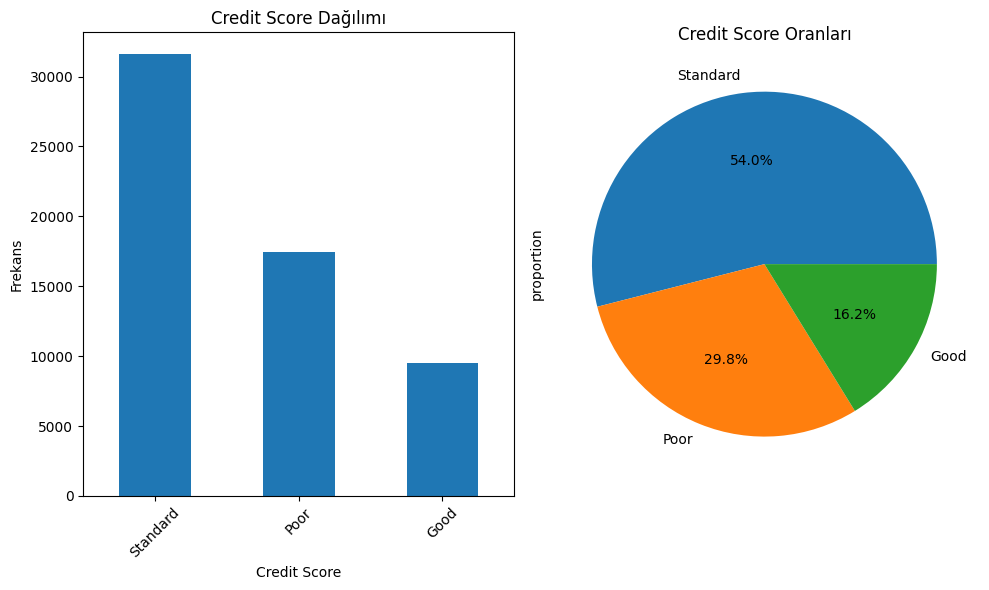

Hedef değişken dağılımı:
en
Standard    31586
Poor        17449
Good         9486
Name: count, dtype: int64


In [12]:
# Hedef değişken dağılımı
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Credit Score Dağılımı')
plt.xlabel('Credit Score')
plt.ylabel('Frekans')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
y_train.value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')
plt.title('Credit Score Oranları')

plt.tight_layout()
plt.show()

print("Hedef değişken dağılımı:")
print(y_train.value_counts())

In [13]:
# Model trainer nesnesini oluştur
trainer = ModelTrainer(random_state=42)
print("✅ Model trainer oluşturuldu")

✅ Model trainer oluşturuldu


In [14]:
# Tüm modelleri eğit
print("🚀 Model eğitimi başlıyor...")
print("Bu işlem birkaç dakika sürebilir...")

models = trainer.train_all(
    X=X_train, 
    y=y_train, 
    groups=customer_ids,  # GroupKFold için
    cv_folds=5
)

print("✅ Tüm modeller eğitildi!")

🚀 Model eğitimi başlıyor...
Bu işlem birkaç dakika sürebilir...
STARTING MODEL TRAINING
Data shape: (58521, 92)
Target classes: 3
--------------------------------------------------
Training Random Forest...
Random Forest CV Score: 0.7146 (±0.0050)
Training LightGBM...
LightGBM CV Score: 0.7190 (±0.0064)
Training XGBoost...
XGBoost CV Score: 0.7193 (±0.0052)
Training Logistic Regression...
Logistic Regression CV Score: 0.6476 (±0.0073)
Creating Ensemble Model...
Ensemble created with: ['XGBoost', 'LightGBM', 'RandomForest']
--------------------------------------------------
TRAINING COMPLETED
✅ Tüm modeller eğitildi!


📊 Cross Validation Sonuçları:
                     CV_Mean    CV_Std
XGBoost             0.719311  0.005161
LightGBM            0.718956  0.006425
RandomForest        0.714576  0.005004
LogisticRegression  0.647640  0.007262


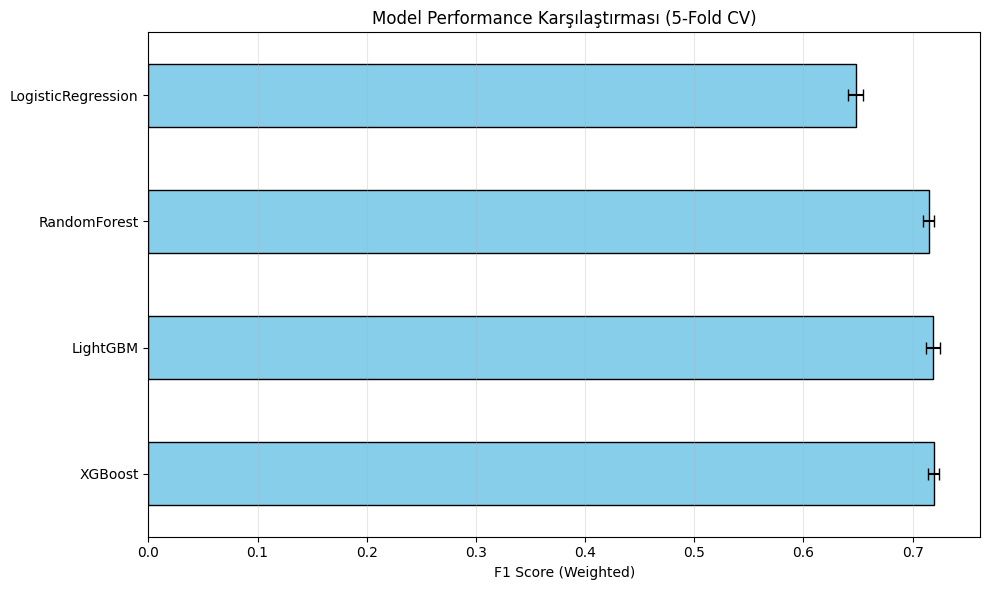

In [15]:
# Cross validation sonuçlarını görüntüle
cv_results = trainer.get_cv_results()
print("📊 Cross Validation Sonuçları:")
print("=" * 40)
print(cv_results)

# Görselleştirme
plt.figure(figsize=(10, 6))
cv_results['CV_Mean'].plot(kind='barh', xerr=cv_results['CV_Std'], 
                           capsize=4, color='skyblue', edgecolor='black')
plt.xlabel('F1 Score (Weighted)')
plt.title('Model Performance Karşılaştırması (5-Fold CV)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Tüm modelleri kaydet
print("💾 Modeller kaydediliyor...")
trainer.save_models(model_dir="../models/")
print("✅ Tüm modeller kaydedildi!")

# Kaydedilen dosyaları listele
import os
model_files = os.listdir("../models/")
print("\nKaydedilen dosyalar:")
for file in sorted(model_files):
    print(f"  📁 {file}")

💾 Modeller kaydediliyor...
Saving models...
Saved: RandomForest -> ../models/randomforest_model.pkl
Saved: LightGBM -> ../models/lightgbm_model.pkl
Saved: XGBoost -> ../models/xgboost_model.pkl
Saved: LogisticRegression -> ../models/logisticregression_model.pkl
Saved: Ensemble -> ../models/ensemble_model.pkl
Saved: Label Encoder -> ../models/label_encoder.pkl
Saved: CV Results -> ../models/cv_results.pkl
All models saved successfully!
✅ Tüm modeller kaydedildi!

Kaydedilen dosyalar:
  📁 cv_results.pkl
  📁 ensemble_model.pkl
  📁 label_encoder.pkl
  📁 lightgbm_model.pkl
  📁 logisticregression_model.pkl
  📁 randomforest_model.pkl
  📁 xgboost_model.pkl


In [17]:
# Model dosya boyutlarını kontrol et
import os

print("📏 Model Dosya Boyutları:")
print("-" * 30)

for file in sorted(os.listdir("../models/")):
    if file.endswith('.pkl'):
        file_path = os.path.join("../models/", file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"{file:<25}: {size_mb:.2f} MB")

📏 Model Dosya Boyutları:
------------------------------
cv_results.pkl           : 0.00 MB
ensemble_model.pkl       : 21.12 MB
label_encoder.pkl        : 0.00 MB
lightgbm_model.pkl       : 1.00 MB
logisticregression_model.pkl: 0.00 MB
randomforest_model.pkl   : 8.43 MB
xgboost_model.pkl        : 1.13 MB


In [18]:
# Eğitim özeti
print("=" * 60)
print("🎯 MODEL EĞİTİMİ TAMAMLANDI!")
print("=" * 60)

print(f"📊 Toplam Model Sayısı: {len(models)}")
print(f"📁 Kaydedilen Konum: ../models/")

print("\n🏆 Model Performansları:")
for idx, (model_name, score) in enumerate(cv_results.iterrows(), 1):
    print(f"{idx}. {model_name:<18}: {score['CV_Mean']:.4f} (±{score['CV_Std']:.4f})")

print("\n📋 Sonraki Adımlar:")
print("  1. 04_evaluation.ipynb notebook'unu çalıştır")
print("  2. Test seti performansını değerlendir")
print("  3. En iyi modeli seç")
print("  4. Model interpretability analizi yap")

print("=" * 60)

🎯 MODEL EĞİTİMİ TAMAMLANDI!
📊 Toplam Model Sayısı: 5
📁 Kaydedilen Konum: ../models/

🏆 Model Performansları:
1. XGBoost           : 0.7193 (±0.0052)
2. LightGBM          : 0.7190 (±0.0064)
3. RandomForest      : 0.7146 (±0.0050)
4. LogisticRegression: 0.6476 (±0.0073)

📋 Sonraki Adımlar:
  1. 04_evaluation.ipynb notebook'unu çalıştır
  2. Test seti performansını değerlendir
  3. En iyi modeli seç
  4. Model interpretability analizi yap


In [19]:
# Memory cleanup
import gc

print("🧹 Memory cleanup...")
del models  # model referanslarını temizle
gc.collect()
print("✅ Cleanup tamamlandı")

🧹 Memory cleanup...
✅ Cleanup tamamlandı
